# Plantalyze model
Modelo de machine learning para detección de especies de plantas a partir de imágenes.

Notebook para probar el modelo y realizar predicciones.

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import kagglehub
from sklearn import metrics
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Hiperparámetros

In [2]:
IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 32

### Importar dataset

In [3]:
path = kagglehub.dataset_download("marquis03/plants-classification")

print("Path to dataset files:", path)

100%|██████████| 1.34G/1.34G [00:16<00:00, 85.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/marquis03/plants-classification/versions/1


In [4]:
test_dir = path + "/test"

Found 6000 images belonging to 30 classes.
(32, 224, 224, 3)


<Figure size 640x480 with 0 Axes>

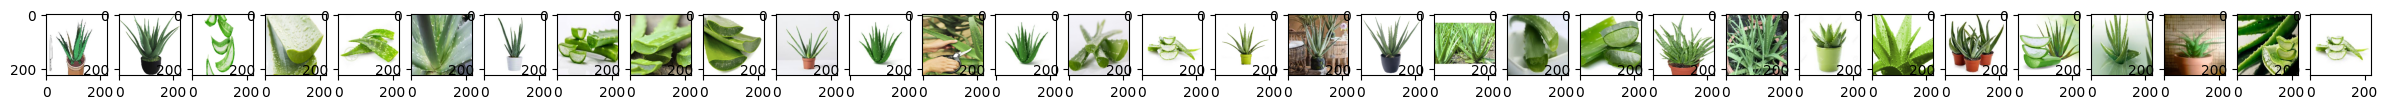

In [5]:
datagen = ImageDataGenerator(rescale=1./255)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

images , labels = test_generator[0]

print(images.shape)

plt.figure()
f, axarr = plt.subplots(1, images.shape[0], figsize=(30, 4))

for i in range(images.shape[0]) :
  axarr[i].imshow(images[i])

### Carga del modelo

In [6]:
def upload_model(path):
  model = load_model(path)
  return model

#### Carga y preprocesamiento de la imagen

In [7]:
def upload_image(path):
  img = image.load_img(
      path, target_size=(IMG_WIDTH, IMG_HEIGHT)
  )
  img_array = image.img_to_array(img)
  img_array = img_array / 255.0
  img_array = tf.expand_dims(img_array, 0)
  return img_array

#### Predicción e interpretación

In [20]:
def predict_image(model, path):
  class_names = {}
  for key, value in test_generator.class_indices.items():
    class_names[value] = key

  image = upload_image(path)
  prediction = model.predict(image)

  class_name = class_names[np.argmax(prediction)]
  prediction_prob = np.max(prediction) * 100
  other_prob = 100 - prediction_prob

  print(f"Clase predicha: {class_name}")
  print(f"Confianza: {prediction_prob:.2f}%")
  print("\nDistribución de probabilidades:")
  for index, probability in enumerate(prediction[0]):
    if probability >= 0.0001:
      print(f"{class_names[index]}: {probability * 100:.2f}%")

#### Predicción y resultados

In [21]:
model = upload_model('/content/drive/MyDrive/Plantalyze/checkpoints/best_model_arq2_v4.keras')
predict_image(model, '/content/drive/MyDrive/Plantalyze/watermelon.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 848ms/step
Clase predicha: watermelon
Confianza: 99.89%

Distribución de probabilidades:
guava: 0.08%
melon: 0.02%
watermelon: 99.89%
